In [ ]:
from icrawler.builtin import BingImageCrawler, GoogleImageCrawler, BaiduImageCrawler, FlickrImageCrawler

# List of breeds to download
breeds = ['murrah']

# Base directory to save images
base_dir = './dataset/train'

# ---- Bing ----
def scrape_bing(breed, limit=50):
    folder_name = breed.replace(' ', '_')
    print(f"[Bing] Downloading images for: {breed}")
    crawler = BingImageCrawler(storage={'root_dir': f'{base_dir}/{folder_name}/bing'})
    crawler.crawl(keyword=breed, max_num=limit)

# ---- Google ----
def scrape_google(breed, limit=30):
    folder_name = breed.replace(' ', '_')
    print(f"[Google] Downloading images for: {breed}")
    crawler = GoogleImageCrawler(storage={'root_dir': f'{base_dir}/{folder_name}/google'})
    crawler.crawl(keyword=breed, max_num=limit)

# ---- Baidu ----
def scrape_baidu(breed, limit=50):
    folder_name = breed.replace(' ', '_')
    print(f"[Baidu] Downloading images for: {breed}")
    crawler = BaiduImageCrawler(storage={'root_dir': f'{base_dir}/{folder_name}/baidu'})
    crawler.crawl(keyword=breed, max_num=limit)


# -------- Run scrapers --------
for breed in breeds:
    scrape_bing(breed, limit=100)     # safer range: 30–80
    scrape_google(breed, limit=20)   # safer range: 20–30
    scrape_baidu(breed, limit=80)    # safer range: 50–100


print("✅ Download complete for all sources!")

[Bing] Downloading images for: murrah


ERROR:downloader:Response status code 400, file https://media.istockphoto.com/id/1402850364/pt/foto/countryside-indian-buffalo-in-junagadh-gir-national-park-murrah-buffalo-morning-time-with.jpg
ERROR:downloader:Response status code 400, file https://media.istockphoto.com/id/484450134/pt/foto/murrah-buffalo.jpg
ERROR:downloader:Response status code 400, file https://media.istockphoto.com/id/1402850381/pt/foto/countryside-indian-buffalo-in-junagadh-gir-national-park-murrah-buffalo-morning-time-with.jpg
ERROR:downloader:Response status code 400, file https://media.istockphoto.com/id/483146724/pt/foto/murrah-buffalo.jpg


[Google] Downloading images for: murrah


ERROR:downloader:Response status code 403, file https://5.imimg.com/data5/ANDROID/Default/2022/2/LN/JB/ZB/11000009/prod-20220203-1922096802863303884592351-jpg
ERROR:downloader:Response status code 400, file https://media.istockphoto.com/id/1402850381/photo/countryside-indian-buffalo-in-junagadh-gir-national-park-murrah-buffalo-morning-time-with.jpg


[Baidu] Downloading images for: murrah


ERROR:downloader:Exception caught when downloading file https://qdpusen.com/uploadfiles/image/20180404/20180404140861906190.jpg, error: HTTPSConnectionPool(host='qdpusen.com', port=443): Max retries exceeded with url: /uploadfiles/image/20180404/20180404140861906190.jpg (Caused by NewConnectionError('<urllib3.connection.HTTPSConnection object at 0x7c20afa2c5c0>: Failed to establish a new connection: [Errno 111] Connection refused')), remaining retry times: 2
ERROR:downloader:Exception caught when downloading file https://qdpusen.com/uploadfiles/image/20180404/20180404140861906190.jpg, error: HTTPSConnectionPool(host='qdpusen.com', port=443): Max retries exceeded with url: /uploadfiles/image/20180404/20180404140861906190.jpg (Caused by NewConnectionError('<urllib3.connection.HTTPSConnection object at 0x7c20afa2fd40>: Failed to establish a new connection: [Errno 111] Connection refused')), remaining retry times: 1
ERROR:downloader:Exception caught when downloading file https://qdpusen.co

✅ Download complete for all sources!


In [ ]:
import os
import shutil
import random

def split_dataset(base_dir, output_dir, train_ratio=0.7, val_ratio=0.2, test_ratio=0.1, seed=42):
    random.seed(seed)

    breeds = os.listdir(base_dir)  # e.g. ['murrah', 'gir']
    for breed in breeds:
        breed_path = os.path.join(base_dir, breed)

        # collect all images from subfolders (baidu, bing, google)
        all_images = []
        for root, _, files in os.walk(breed_path):
            for f in files:
               if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                    all_images.append(os.path.join(root, f))

        print(f"{breed}: {len(all_images)} images found")

        random.shuffle(all_images)

        # split sizes
        n_total = len(all_images)
        n_train = int(train_ratio * n_total)
        n_val = int(val_ratio * n_total)

        train_imgs = all_images[:n_train]
        val_imgs = all_images[n_train:n_train+n_val]
        test_imgs = all_images[n_train+n_val:]

        # save into new structure
        for split, imgs in zip(['train', 'val', 'test'], [train_imgs, val_imgs, test_imgs]):
            split_dir = os.path.join(output_dir, split, breed)
            os.makedirs(split_dir, exist_ok=True)

            for img_path in imgs:
                fname = os.path.basename(img_path)
                shutil.copy(img_path, os.path.join(split_dir, fname))

        print(f"✅ {breed}: Train={len(train_imgs)}, Val={len(val_imgs)}, Test={len(test_imgs)}")

# ----------------- Run -----------------
base_dir = "/content/dataset/train"   # where murrah/gir folders with baidu/bing/google exist
output_dir = "/content/dataset_split" # new organized dataset

split_dataset(base_dir, output_dir)

murrah: 119 images found
✅ murrah: Train=83, Val=23, Test=13
Gir_cattle: 199 images found
✅ Gir_cattle: Train=139, Val=39, Test=21


In [ ]:
# --------------------------
# Step 0: Mount Google Drive
# --------------------------
from google.colab import drive
drive.mount('/content/drive')

# Replace this with your folder path in Drive
data_dir = "/content/drive/MyDrive/DAIRY CATTLE/cow"  # must have subfolders Breed1, Breed2
split_dir = "/content/drive/MyDrive/DAIRY CATTLE/data_split"  # temporary working split folder in Colab
!mkdir -p {split_dir}/train {split_dir}/val {split_dir}/test

# --------------------------
# Step 1: Split dataset
# --------------------------
import os
from sklearn.model_selection import train_test_split

def split_data(class_name, test_size=0.2, val_size=0.1, seed=42):

# --------------------------
# Step 2: Load datasets with batching
# --------------------------
import tensorflow as tf
from tensorflow.keras import layers

batch_size = 32
img_size = (224, 224)

train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(split_dir, "train"),
    image_size=img_size,
    batch_size=batch_size
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(split_dir, "val"),
    image_size=img_size,
    batch_size=batch_size
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(split_dir, "test"),
    image_size=img_size,
    batch_size=batch_size
)

# --------------------------
# Step 3: Data augmentation (training only)
# --------------------------
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))
train_ds = train_ds.prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

print("Datasets are ready for training on Colab!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


ValueError: With n_samples=0, test_size=0.30000000000000004 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

In [ ]:
# TensorFlow (for model training)
!pip install tensorflow --upgrade

# scikit-learn (for splitting data if needed)
!pip install scikit-learn --upgrade

# Optional: matplotlib (for plotting training metrics)
!pip install matplotlib --upgrade

# Optional: Pillow (for image handling, usually comes with TF)
!pip install Pillow --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 742.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 101.6 MB/s eta 0:00:00
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.19.0
    Uninstalling tensorboard-2.19.0:
      Successfully uninstalled tensorboard-2.19.0
  Attempting uninstall: tensorflow
    Found existing installation: tensorflow 2.19.0
    Uninstalling tensorflow-2.19.0:
      Successfully uninstalled tensorflow-2.19.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-decision-forests 1.12.0 requires tensorflow==2.19.0, but you have tensorflow 2.20.0 which is incompatible.
tf-keras 2.19.0 requires tensorflow<2.20,>=2.19, but you have tensorflow 2.20.0 which is incompatible.
tensorflow-text 2.19.0 requires tensorflow<2.20,>=2.19.0, but you have tensorflow 2.20.0 which is i

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 62.8 MB/s eta 0:00:00
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.10.0
    Uninstalling matplotlib-3.10.0:
      Successfully uninstalled matplotlib-3.10.0


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
^C


In [ ]:
# ==========================
# Step 0: Imports
# ==========================
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping
import os

# ==========================
# Step 1: Dataset Paths & Parameters
# ==========================
split_dir = "/content/drive/MyDrive/DAIRY CATTLE/data_split"
batch_size = 32
img_size = (224, 224)

# ==========================
# Step 2: Load Datasets
# ==========================
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(split_dir, "train"),
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(split_dir, "val"),
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(split_dir, "test"),
    image_size=img_size,
    batch_size=batch_size,
    shuffle=False
)

# ==========================
# Step 3: Class Names (SAFE)
# ==========================
class_names = train_ds.class_names
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)

assert num_classes == 2, "This code is for binary classification only!"

# ==========================
# Step 4: Data Augmentation
# ==========================
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))

# ==========================
# Step 5: MobileNetV2 Preprocessing (CRITICAL)
# ==========================
preprocess = tf.keras.applications.mobilenet_v2.preprocess_input

train_ds = train_ds.map(lambda x, y: (preprocess(x), y))
val_ds   = val_ds.map(lambda x, y: (preprocess(x), y))
test_ds  = test_ds.map(lambda x, y: (preprocess(x), y))

# ==========================
# Step 6: Performance Optimization
# ==========================
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds   = val_ds.prefetch(AUTOTUNE)
test_ds  = test_ds.prefetch(AUTOTUNE)

# ==========================
# Step 7: Build Model
# ==========================
base_model = MobileNetV2(
    input_shape=img_size + (3,),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False  # Freeze base model

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")  # Binary output
])

# ==========================
# Step 8: Compile Model
# ==========================
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# ==========================
# Step 9: Train Model
# ==========================
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop]
)

# ==========================
# Step 10: Evaluate Model
# ==========================
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Accuracy: {test_acc * 100:.2f}%")

# ==========================
# Step 11: Save Model
# ==========================
model.save("/content/drive/MyDrive/DAIRY CATTLE/gir_vs_sahiwal_BINARY.h5")
print("Model saved successfully!")


Found 476 files belonging to 2 classes.
Found 69 files belonging to 2 classes.
Found 137 files belonging to 2 classes.
Classes: ['Gir', 'sahiwal']
Number of classes: 2


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.5396 - loss: 0.7548 - val_accuracy: 0.6087 - val_loss: 0.6085
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step - accuracy: 0.6758 - loss: 0.6036 - val_accuracy: 0.7826 - val_loss: 0.5219
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.8112 - loss: 0.4610 - val_accuracy: 0.6812 - val_loss: 0.5611
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 0.7930 - loss: 0.4541 - val_accuracy: 0.8551 - val_loss: 0.4492
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 0.7747 - loss: 0.4442 - val_accuracy: 0.7391 - val_loss: 0.5049
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.8282 - loss: 0.3728 - val_accuracy: 0.7971 - val_loss: 0.4444
Epoch 7/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 0.7895 - loss: 0.3988 - val_accuracy: 0.7536 - val_loss: 0.4879
Epoch 8/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 0.8518 - loss: 0.3219 - val_accuracy: 0.8261 - val_loss:

Test Accuracy: 83.94%
Model saved successfully!


Class names: ['Gir', 'sahiwal']
Upload one or more cow images to predict their breed:


Saving images.jpg to images (2).jpg
Saving Brown-Gir-Cow.jpg to Brown-Gir-Cow (2).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Raw model output (P[sahiwal]): 0.8514917


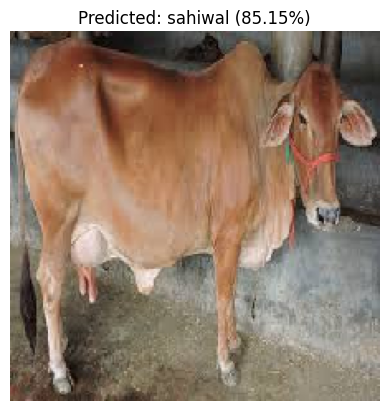

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
Raw model output (P[sahiwal]): 0.2895543


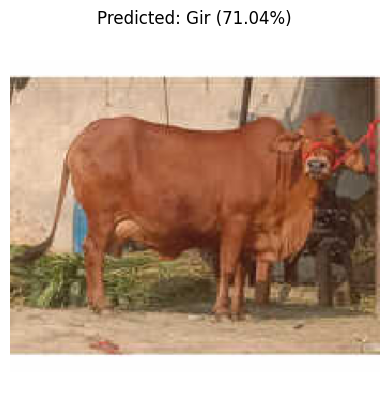

In [ ]:
# --------------------------
# Step 0: Imports
# --------------------------
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import os
from google.colab import files

# --------------------------
# Step 1: Load the trained model
# --------------------------
model_path = "/content/drive/MyDrive/DAIRY CATTLE/gir_vs_sahiwal_BINARY.h5"
model = tf.keras.models.load_model(model_path)

# Get class names from your training folder
split_dir = "/content/drive/MyDrive/DAIRY CATTLE/data_split"
class_names = sorted([
    d for d in os.listdir(os.path.join(split_dir, "train"))
    if os.path.isdir(os.path.join(split_dir, "train", d)) and not d.startswith('.')
])
print("Class names:", class_names)
# --------------------------
# Step 2: Prediction function
# --------------------------
def predict_breed(img_path, model, img_size=(224, 224)):
    # Load image
    img = image.load_img(img_path, target_size=img_size)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    # CORRECT preprocessing
    img_array = preprocess_input(img_array)

    # Predict
    prob = model.predict(img_array)[0][0]  # sigmoid output

    # CORRECT label logic
    if prob >= 0.6:
        breed_name = "sahiwal"
        confidence = prob
    elif prob <= 0.4:
        breed_name = "Gir"
        confidence = 1 - prob
    else:
        breed_name = "Unknown / Cross-breed"
        confidence = prob

    # Debug print
    print("Raw model output (P[sahiwal]):", prob)

    # Display
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Predicted: {breed_name} ({confidence*100:.2f}%)")
    plt.show()
# --------------------------
# Step 3: Upload multiple images
# --------------------------
print("Upload one or more cow images to predict their breed:")
uploaded = files.upload()

for img_path in uploaded.keys():
    predict_breed(img_path, model)